In [1]:
# Modelado
#import tensorflow as tf # no se requiere
#from tensorflow import keras # no se requiere
#from keras.models import Sequential # no se requiere
#from keras import Input # no se requiere
#from keras.layers import Dense, SimpleRNN # no se requiere
import neuralprophet

import sys
sys.path.append(r'c:\Users\JUAN DAVID\Desktop\maestria docs\codigo python\utils')
from functions import symmetric_mean_absolute_percentage_error
# procesamiento
import pandas as pd
import numpy as np
import json
# ml, procesamiento
#import sklearn
from sklearn.model_selection import TimeSeriesSplit
#from sklearn.model_selection import train_test_split # no se requiere
from sklearn.preprocessing import MinMaxScaler 
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# analisis series de tiempo
#from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # no se requiere
#from statsmodels.tsa.stattools import adfuller # no se requiere

# optimización, warnings
import optuna
import warnings
import optuna.visualization as vis
warnings.filterwarnings("ignore")

# visual
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("viridis")

# semilla para reproductibilidad
# configuración de reproductbilidad
np.random.seed(42)


c:\Users\JUAN DAVID\Desktop\maestria docs\codigo python\venv_tesis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


In [2]:
# carga de datos desde archivos csv
# se descomentan solo los de nvidia y syp 
tickets = [
    "NVDA",
    "^SPX"
    #"AMD",
    #"BTC-USD",
    #"^NDX",
    #"^VIX",
    #"UBSFY"
]
# se cargan las fechas
dates = pd.read_csv("../data/csv/SPX_data.csv")
# se crea un dataframe con las fechas de close para almacenar los precios de cierre
date_close = pd.DataFrame({
    "Date": pd.to_datetime(dates["Date"])
})

# se recorren los tickets, se lee el archivo asociado al ticket y se
# carga en el df el precio de cierre

for ticket in tickets: 
    file_name = ticket.replace("^", "") # se quita el caracter ^
    data_ticket = pd.read_csv(f"../data/csv/{file_name}_data.csv") # se lee el archivo csv del ticket correspondiente
    data_ticket["Date"] = pd.to_datetime(data_ticket["Date"]) # se formatea la columna Date a fecha

    # se define el nombre de la columna de precios de cierre
    close_column = f"{file_name}_Close"

    # se hace left join del df de las fechas con el df del ticket creado, por fechas
    date_close = pd.merge(
        date_close, # primer df
        data_ticket[["Date", close_column]].rename(columns={close_column: file_name}),
        # se escogen las columnas date y cierre del df del ticket y se renombra la columna de precio de cierre con el nombre del ticket
        on="Date", # columna para hacer el merge
        how="left" # tipo de merge
    )

In [3]:
df_data_close = pd.DataFrame(date_close.copy()) # copia del df de precios de cierre como df
df_dat_close = df_data_close.sort_values(by="Date", ascending=True) # se ordena por fecha ascendente
df_data_close.head()

,Date,NVDA,SPX
0,2021-01-04,13.077454,3700.649902
1,2021-01-05,13.367903,3726.860107
2,2021-01-06,12.579826,3748.139893
3,2021-01-07,13.307321,3803.790039
4,2021-01-08,13.240253,3824.679932


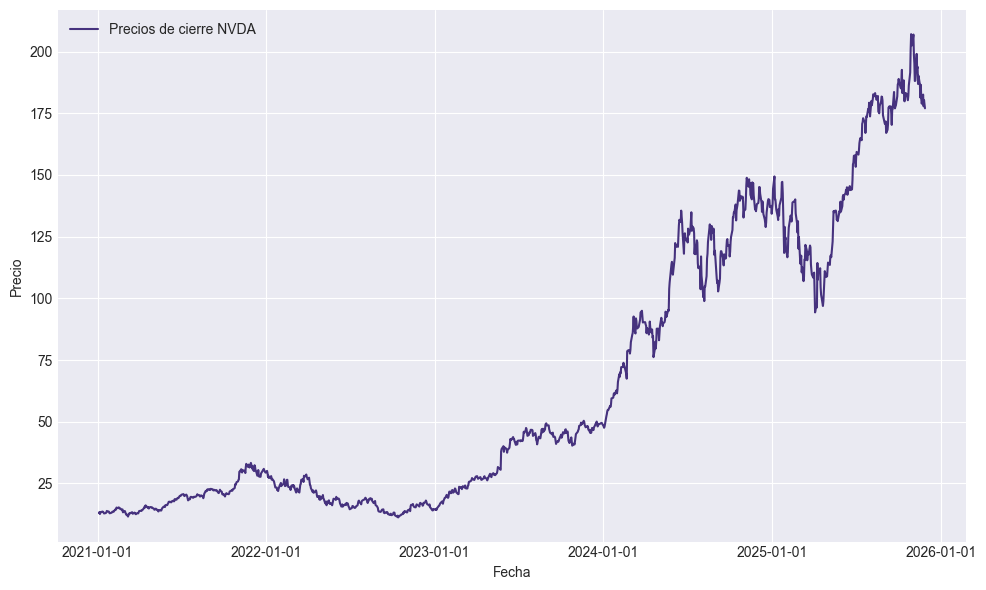

In [4]:
# se grafican los datos de cierre de la serie 
plt.figure(figsize=(10,6))
plt.plot(df_data_close["Date"], df_data_close["NVDA"], label="Precios de cierre NVDA")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

In [5]:
df_data_close = df_data_close.rename(columns={'Date': 'ds', 'NVDA': 'y'})
df = df_data_close
df.head()

,ds,y,SPX
0,2021-01-04,13.077454,3700.649902
1,2021-01-05,13.367903,3726.860107
2,2021-01-06,12.579826,3748.139893
3,2021-01-07,13.307321,3803.790039
4,2021-01-08,13.240253,3824.679932


In [6]:
# se hace una copia para la manipulación de los datos y se deja un porcentaje para extrapolar el comportamiento del modelo
df_data_close_copy = df_data_close.copy()
#forecast_size = 20 # porcentaje de datos para folds
percentage = 0.95
folds_data_size = int(len(df_data_close_copy) * percentage) # tamaño de los datos para folds
folds_data = df_data_close_copy.iloc[:folds_data_size] # datos para folds
val_data = df_data_close_copy.iloc[folds_data_size:] # datos para validación final

# se calcula la fecha donde se toman los datos de validación
#val_start_date = folds_data["Date"][-1:].values[0]
val_start_date = val_data["ds"].iloc[0]

#val_start_date["Date"] 

len(val_data)

62

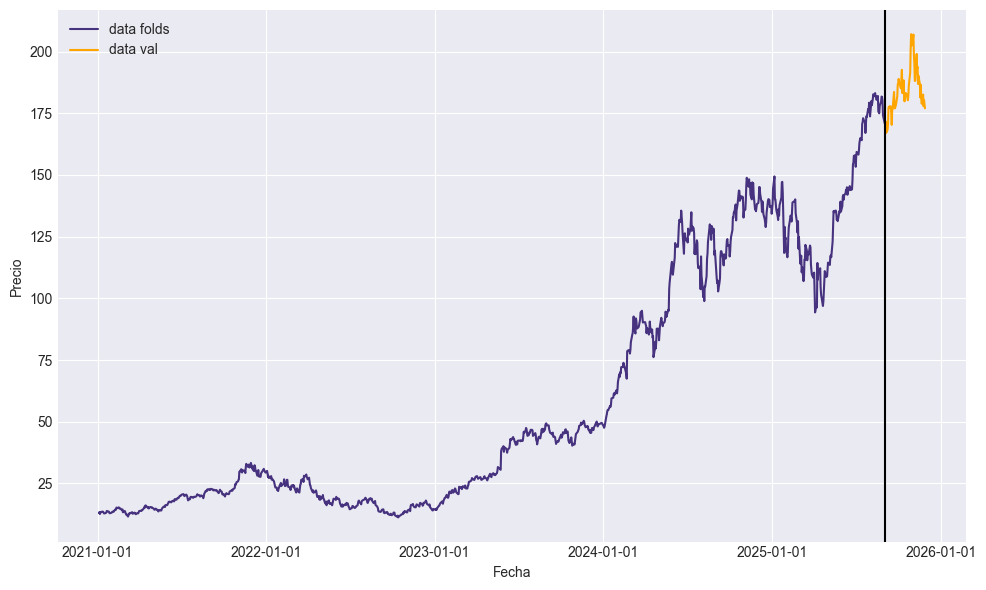

In [7]:
# se grafican los datos de cierre de la serie 
plt.figure(figsize=(10,6))
plt.plot(folds_data["ds"], folds_data["y"], label="data folds")
plt.plot(val_data["ds"], val_data["y"], label="data val", color='orange')
plt.axvline(val_start_date, color="black")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

In [8]:
# las features deben estar en la misma escala (se debe definir el regresor dentro del modelo antes de entrenarlo. Si se define despues, toca hacer todo de cero)
model = neuralprophet.NeuralProphet(
    n_changepoints = 50,
    n_forecasts=1,
    yearly_seasonality = False,
    weekly_seasonality= False,
    daily_seasonality = False,
    n_lags=len(val_data)
)
model.add_lagged_regressor("SPX", n_lags = 3)
model.add_country_holidays(country_name='US')
model.set_plotting_backend("plotly")
metrics = model.fit(folds_data)


WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 95.986% of the data.
INFO - (NP.df_utils._infer_frequency) - Dataframe freq automatically defined as B
INFO - (NP.data.processing._handle_missing_data) - Added 46 missing dates.
WARNING - (NP.data.processing._handle_missing_data) - 46 missing values in column y were detected in total. 
INFO - (NP.data.processing._handle_missing_data) - 46 NaN values in column y were auto-imputed.
WARNING - (NP.data.processing._handle_missing_data) - 46 missing values in column SPX were detected in total. 
INFO - (NP.data.processing._handle_missing_data) - 46 NaN values in column SPX were auto-imputed.
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 32
INFO - (NP.config.set_auto_bat

Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (37) is too small than the required number                     for the learning rate finder (227). The results might not be optimal.
Finding best initial lr: 100%|██████████| 227/227 [00:05<00:00, 41.56it/s]


Training: |          | 0/? [01:07<?, ?it/s, v_num=10, train_loss=0.0068, reg_loss=0.000, MAE=6.560, RMSE=9.010, Loss=0.00695, RegLoss=0.000] 


In [9]:
future_df = model.make_future_dataframe(folds_data, periods=len(val_data))



INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 95.986% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - B
WARNING - (NP.data.splitting._make_future_dataframe) - Number of forecast steps is defined by n_forecasts. Adjusted to 1.
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


In [10]:
len(future_df)

63

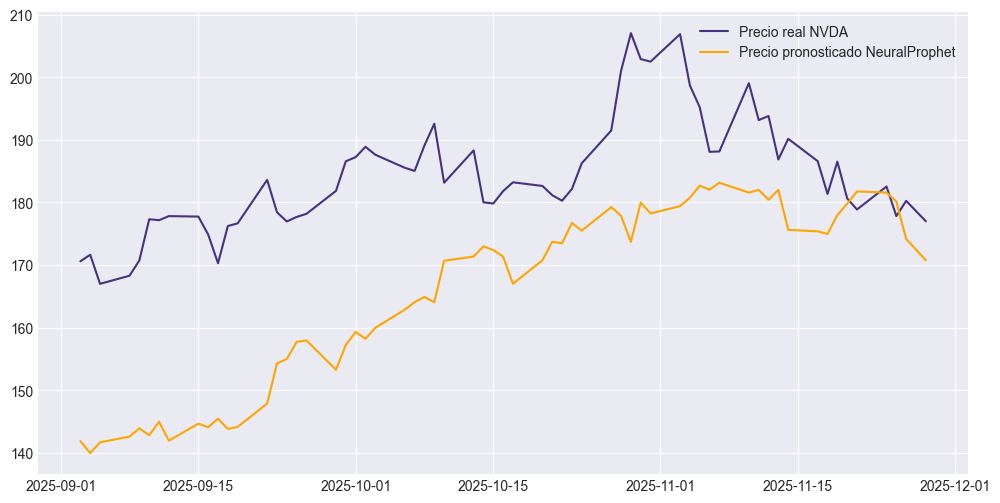

In [11]:
plt.figure(figsize=(12,6))
#plt.plot(df_data_close["Date"][:-len(val_data)], df_data_close["NVDA"][:-len(val_data)], label="Precio real NVDA - train", color="gray")
plt.plot(val_data["ds"], val_data["y"], label="Precio real NVDA")
plt.plot(val_data["ds"], future_df["y"][:-1], label="Precio pronosticado NeuralProphet", color="orange")
plt.legend()
plt.show()